In [2]:
import os
import random
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import mixed_precision

# Aktifkan Turbo GPU agar komputasi 2x lebih cepat
mixed_precision.set_global_policy('mixed_float16')
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-06-14 13:22:01.641594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781443321.814537      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781443321.867536      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781443322.288865      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781443322.288914      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781443322.288917      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import os
import random

# Scan path input Kaggle
INPUT_DIR = "/kaggle/input/datasets/wish096/realvsfake-81k-by-wish/RealVsFake/RealVsFake"
WORK_DIR = "/kaggle/working/dataset_ready"

os.makedirs(f"{WORK_DIR}/real", exist_ok=True)
os.makedirs(f"{WORK_DIR}/fake", exist_ok=True)

file_dict = {
    'RFF': [], 'RCA': [],
    'FSG': [], 'FSD': [], 'AI': []
}

print("Scanning struktur file dataset...")
for root, _, files in os.walk(INPUT_DIR):
    for file in files:
        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        path = os.path.join(root, file)
        if file.startswith('RFF'):   file_dict['RFF'].append(path)
        elif file.startswith('RCA'): file_dict['RCA'].append(path)
        elif file.startswith('FSG'): file_dict['FSG'].append(path)
        elif file.startswith('FSD'): file_dict['FSD'].append(path)
        elif file.startswith('AI'):  file_dict['AI'].append(path)

for k, v in file_dict.items():
    print(f"  {k}: {len(v)} file ditemukan")

def create_symlinks_from_list(file_list, target_dir, num_samples, prefix=""):
    sampled_files = random.sample(file_list, min(num_samples, len(file_list)))
    count = 0
    for i, file_path in enumerate(sampled_files):
        symlink_name = os.path.join(target_dir, f"{prefix}_{i}.jpg")
        if not os.path.exists(symlink_name):
            os.symlink(file_path, symlink_name)
            count += 1
    return count

print("\nMulai meracik dataset seimbang (Target: 20.000 data)...")

c_rff = create_symlinks_from_list(file_dict['RFF'], f"{WORK_DIR}/real", 5000, prefix="real_ffhq")
c_rca = create_symlinks_from_list(file_dict['RCA'], f"{WORK_DIR}/real", 5000, prefix="real_celeba")

c_fsg = create_symlinks_from_list(file_dict['FSG'], f"{WORK_DIR}/fake", 5000, prefix="fake_stylegan")
c_fsd = create_symlinks_from_list(file_dict['FSD'], f"{WORK_DIR}/fake", 4000, prefix="fake_diffusion")
c_ai  = create_symlinks_from_list(file_dict['AI'],  f"{WORK_DIR}/fake", 1000, prefix="fake_aigen")

total_real = c_rff + c_rca
total_fake = c_fsg + c_fsd + c_ai
print("\n✅ Dataset Berhasil Dirancang!")
print(f"📸 REAL : {total_real} gambar (FFHQ: {c_rff} | CelebA: {c_rca})")
print(f"🤖 FAKE : {total_fake} gambar (StyleGAN: {c_fsg} | Diffusion: {c_fsd} | AiGen: {c_ai})")
print(f"\n📁 Dataset tersimpan di: {WORK_DIR}")

Scanning struktur file dataset...
  RFF: 40500 file ditemukan
  RCA: 40500 file ditemukan
  FSG: 70000 file ditemukan
  FSD: 9971 file ditemukan
  AI: 1001 file ditemukan

Mulai meracik dataset seimbang (Target: 20.000 data)...

✅ Dataset Berhasil Dirancang!
📸 REAL : 10000 gambar (FFHQ: 5000 | CelebA: 5000)
🤖 FAKE : 10000 gambar (StyleGAN: 5000 | Diffusion: 4000 | AiGen: 1000)

📁 Dataset tersimpan di: /kaggle/working/dataset_ready


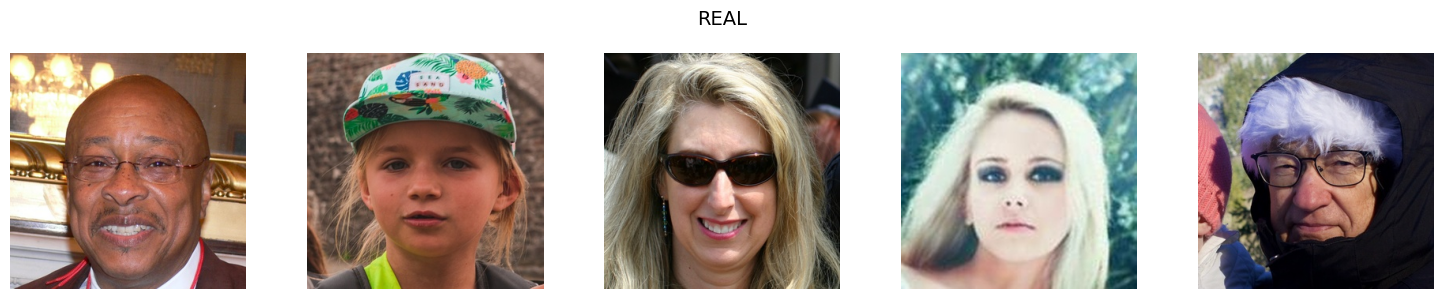

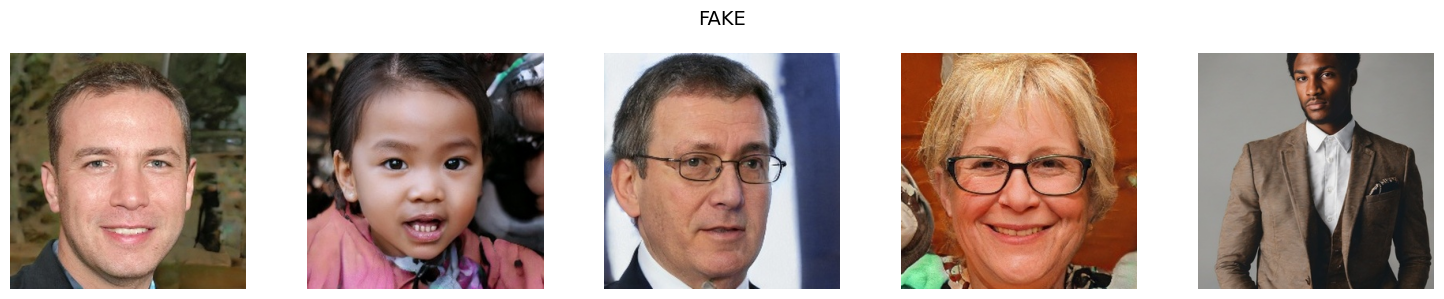

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

for label in ["real", "fake"]:
    files = list(Path(f"{WORK_DIR}/{label}").iterdir())[:5]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(label.upper(), fontsize=14)
    for ax, f in zip(axes, files):
        img = plt.imread(f)
        ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Load data tanpa memenuhi RAM
train_ds = tf.keras.utils.image_dataset_from_directory(
    WORK_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    WORK_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

# Optimasi Cache & Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


In [10]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = True

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 4,011,389 (15.30 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [11]:
checkpoint_cb = callbacks.ModelCheckpoint("best_deepfake_model.keras", save_best_only=True, monitor="val_accuracy")
early_stopping_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss")
reduce_lr_cb = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

print("Memulai proses Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)
print("Selesai! Model disimpan sebagai 'best_deepfake_model.keras'")

Memulai proses Training...
Epoch 1/10


I0000 00:00:1781443798.753990     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


500/500 ━━━━━━━━━━━━━━━━━━━━ 271s 323ms/step - accuracy: 0.8792 - auc: 0.9557 - loss: 0.2790 - val_accuracy: 0.8223 - val_auc: 0.9494 - val_loss: 0.6579 - learning_rate: 1.0000e-04
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 297ms/step - accuracy: 0.9653 - auc: 0.9944 - loss: 0.0912 - val_accuracy: 0.8662 - val_auc: 0.9689 - val_loss: 0.4820 - learning_rate: 1.0000e-04
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 296ms/step - accuracy: 0.9804 - auc: 0.9979 - loss: 0.0535 - val_accuracy: 0.9047 - val_auc: 0.9789 - val_loss: 0.3525 - learning_rate: 1.0000e-04
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 297ms/step - accuracy: 0.9839 - auc: 0.9987 - loss: 0.0409 - val_accuracy: 0.9373 - val_auc: 0.9868 - val_loss: 0.2315 - learning_rate: 1.0000e-04
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 293ms/step - accuracy: 0.9889 - auc: 0.9991 - loss: 0.0299 - val_accuracy: 0.9365 - val_auc: 0.9867 - val_loss: 0.2253 - learning_rate: 1.0000e-04
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 148s 296ms/

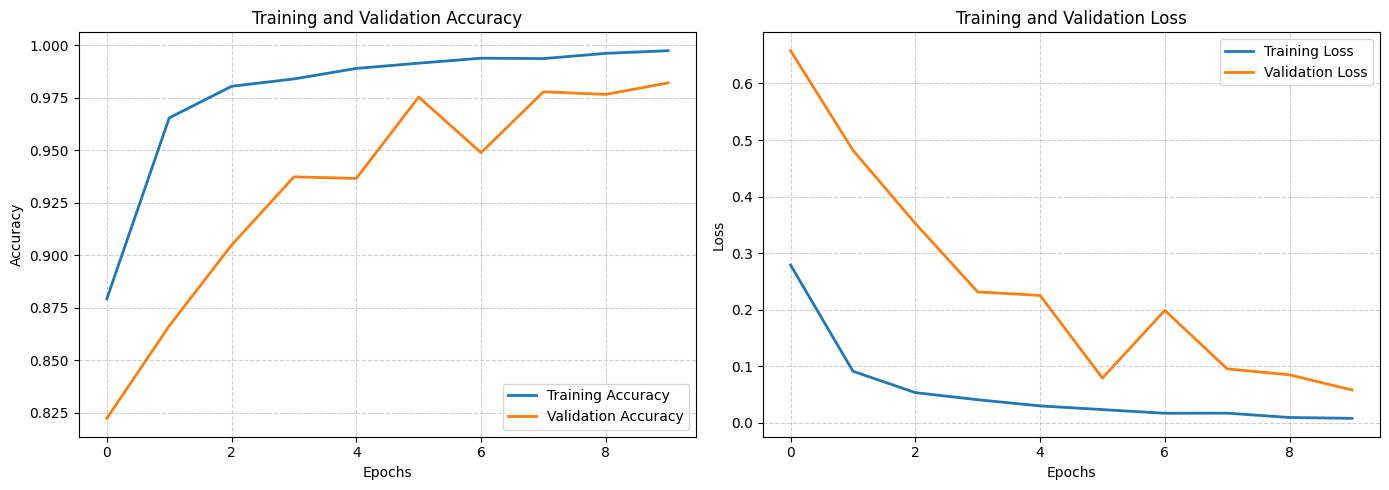

In [12]:
import matplotlib.pyplot as plt

# Pastikan variabel 'history' ada dari proses training sebelumnya
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

1. Memuat model terbaik...
2. Melakukan prediksi pada dataset validasi (Harap tunggu)...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Real (0)       0.97      1.00      0.98      1966
    Fake (1)       1.00      0.97      0.98      2034

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000


--- MENGGAMBAR CONFUSION MATRIX ---


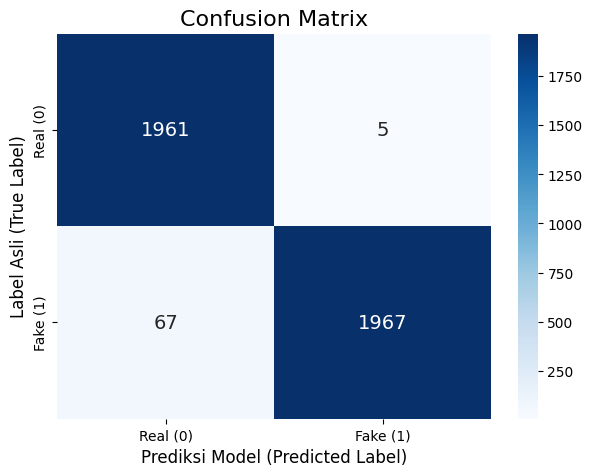

In [13]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("1. Memuat model terbaik...")
best_model = tf.keras.models.load_model("best_deepfake_model.keras")

print("2. Melakukan prediksi pada dataset validasi (Harap tunggu)...")
y_true = []
y_pred_probs = []

# Iterasi melalui seluruh batch di dataset validasi
for images, labels in val_ds:
    # Simpan label asli
    y_true.extend(labels.numpy())

    # Lakukan prediksi
    preds = best_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

# Konversi ke array numpy
y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()

# Ubah probabilitas (0.0 - 1.0) menjadi label kelas biner (0 atau 1)
# dengan nilai tengah (threshold) 0.5
y_pred = (y_pred_probs > 0.5).astype(int)

print("\n--- CLASSIFICATION REPORT ---")
# Menampilkan metrik Precision, Recall, dan F1-Score
target_names = ['Real (0)', 'Fake (1)']
print(classification_report(y_true, y_pred, target_names=target_names))

print("\n--- MENGGAMBAR CONFUSION MATRIX ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            annot_kws={"size": 14}) # Ukuran font angka

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Prediksi Model (Predicted Label)', fontsize=12)
plt.show()

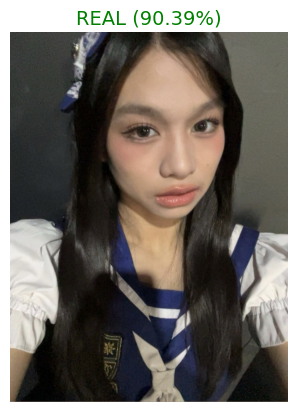

Hasil: REAL | Confidence: 90.39%


In [32]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = load_model("best_deepfake_model.keras")

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]
    label = "FAKE" if pred > 0.5 else "REAL"
    confidence = pred if pred > 0.5 else 1 - pred

    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(f"{label} ({confidence*100:.2f}%)", fontsize=14,
              color="red" if label == "FAKE" else "green")
    plt.show()
    print(f"Hasil: {label} | Confidence: {confidence*100:.2f}%")

# Ganti path sesuai gambar yang ingin diuji
predict_image("/kaggle/input/datasets/sitifadhilahrahmi/gambarasli/HKLgcCAbsAAqeGU.jpeg")